In [2]:
import random
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import (
    DataLoader,
    random_split
)

from torchvision import datasets, transforms


In [3]:
#Reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [4]:
#Select device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


Device: cpu


In [5]:
#Load MNIST

transform = transforms.ToTensor()

full_dataset = datasets.MNIST(
    root="data/raw",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data/raw",
    train=False,
    download=True,
    transform=transform
)


In [6]:
# Train/validation split
train_dataset, val_dataset = random_split(
    full_dataset,
    [50000, 10000],
    generator=torch.Generator().manual_seed(SEED)
)


In [ ]:
# Create DataLoaders

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


In [ ]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)


Images: torch.Size([64, 1, 28, 28])
Labels: torch.Size([64])


In [9]:
# Build the ANN

class MNIST_ANN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(784, 128),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )

    def forward(self, x):

        return self.network(x)


In [10]:
# Create the model

model = MNIST_ANN().to(device)

print(model)


MNIST_ANN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [11]:
# Define loss function

criterion = nn.CrossEntropyLoss()


In [ ]:
# optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


In [13]:
#Training function

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy


In [14]:
# Validation function
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy


In [15]:
#Training loop
EPOCHS = 10


In [16]:
# Create history

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}


In [17]:
# Create checkpoint variables
best_val_accuracy = 0


In [18]:
# train

for epoch in range(EPOCHS):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "models/pytorch/best_model.pth"
        )

        print("Best model saved!")


Epoch [1/10] | Train Loss: 0.3518 | Val Loss: 0.1852 | Train Acc: 0.9043 | Val Acc: 0.9455
Best model saved!
Epoch [2/10] | Train Loss: 0.1965 | Val Loss: 0.1374 | Train Acc: 0.9415 | Val Acc: 0.9597
Best model saved!
Epoch [3/10] | Train Loss: 0.1578 | Val Loss: 0.1188 | Train Acc: 0.9527 | Val Acc: 0.9626
Best model saved!
Epoch [4/10] | Train Loss: 0.1377 | Val Loss: 0.1071 | Train Acc: 0.9582 | Val Acc: 0.9651
Best model saved!
Epoch [5/10] | Train Loss: 0.1216 | Val Loss: 0.1014 | Train Acc: 0.9632 | Val Acc: 0.9689
Best model saved!
Epoch [6/10] | Train Loss: 0.1121 | Val Loss: 0.0979 | Train Acc: 0.9659 | Val Acc: 0.9703
Best model saved!
Epoch [7/10] | Train Loss: 0.1039 | Val Loss: 0.0940 | Train Acc: 0.9682 | Val Acc: 0.9699
Epoch [8/10] | Train Loss: 0.0963 | Val Loss: 0.0883 | Train Acc: 0.9704 | Val Acc: 0.9730
Best model saved!
Epoch [9/10] | Train Loss: 0.0875 | Val Loss: 0.0815 | Train Acc: 0.9730 | Val Acc: 0.9747
Best model saved!
Epoch [10/10] | Train Loss: 0.0828 | 

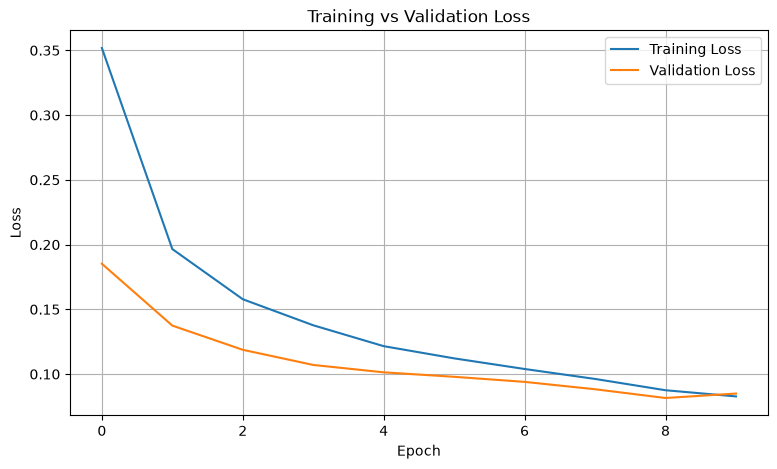

In [19]:
# Plot training/validation loss

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()


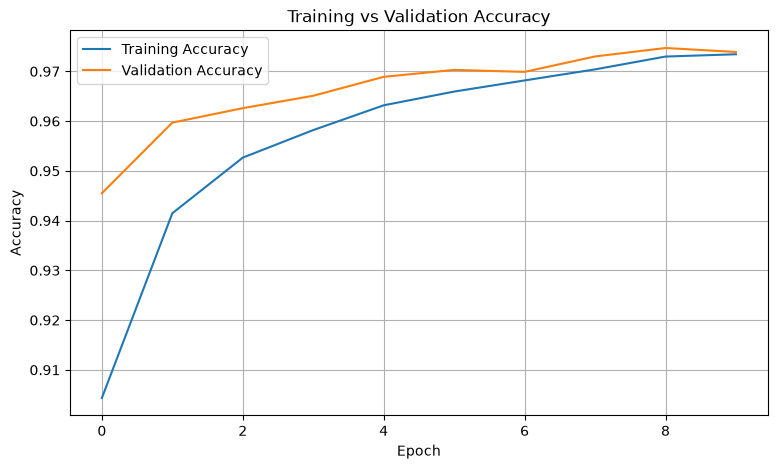

In [20]:
#Plot training/validation accuracy

plt.figure(figsize=(9, 5))

plt.plot(
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()


In [21]:
#Load the best model

model.load_state_dict(
    torch.load(
        "models/pytorch/best_model.pth",
        map_location=device,
        weights_only=True
    )
)


<All keys matched successfully>

In [22]:
#Final testing
test_loss, test_accuracy = validate(
    model,
    test_loader,
    criterion,
    device
)

print(
    f"Test Loss: {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)


Test Loss: 0.0774
Test Accuracy: 0.9761


In [ ]:
#Make predictions

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)


In [ ]:
#Prediction

model.eval()

with torch.no_grad():

    outputs = model(images)

    predictions = torch.argmax(
        outputs,
        dim=1
    )


In [ ]:
print("Predictions:", predictions[:10])
print("Actual:", labels[:10])


Predictions: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])
Actual: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


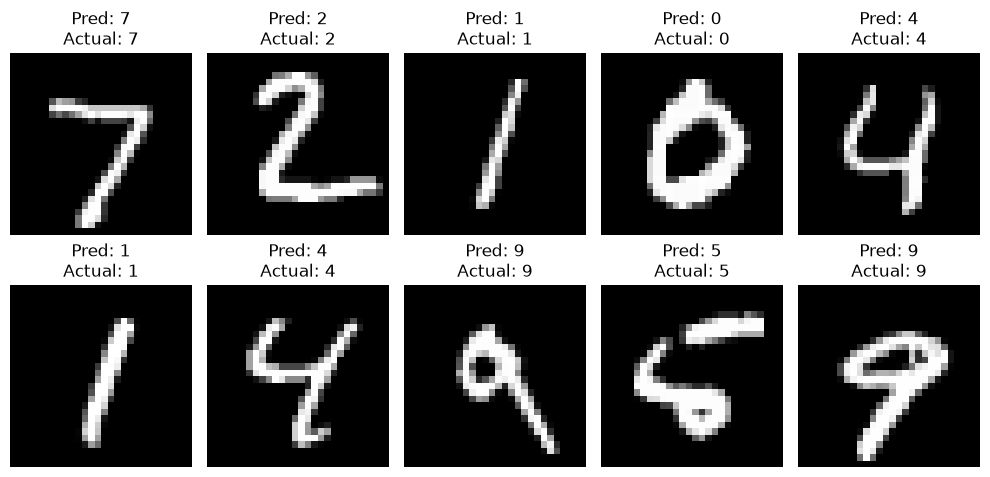

In [ ]:
# Visualize predictions

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].cpu().squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Pred: {predictions[i].item()}\n"
        f"Actual: {labels[i].item()}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


In [27]:
import mlflow

mlflow.set_tracking_uri(
    "http://localhost:5000"
)

mlflow.set_experiment(
    "MNIST ANN"
)


c:\Users\user\OneDrive\Desktop\Bridgeon\Practical\DeepLearning\DeepLearing-week-1\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/08/11 16:24:41 INFO mlflow.tracking.fluent: Experiment with name 'MNIST ANN' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/8', creation_time=1786445681439, effective_trace_archival_retention=None, experiment_id='8', last_update_time=1786445681439, lifecycle_stage='active', name='MNIST ANN', tags={}, trace_location=None, workspace='default'>

In [28]:
with mlflow.start_run(
    run_name="ANN_BatchNorm_Dropout_Adam"
):

    mlflow.log_params({
        "model": "ANN",
        "hidden_size": 128,
        "dropout": 0.3,
        "batch_norm": True,
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "batch_size": 64,
        "epochs": 10
    })

    # Your training loop goes here

    mlflow.log_metric(
        "best_val_accuracy",
        best_val_accuracy
    )

    mlflow.log_metric(
        "test_accuracy",
        test_accuracy
    )


🏃 View run ANN_BatchNorm_Dropout_Adam at: http://localhost:5000/#/experiments/8/runs/1598bafe95cb42189cd9c20b724734de
🧪 View experiment at: http://localhost:5000/#/experiments/8


In [29]:
mlflow.log_metrics(
    {
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy
    },
    step=epoch
)
